# Does a fading RSI really call the bottom? 📉📈
### Bullish RSI divergence — one of the most-taught chart patterns, tested against 16 years of daily data

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_random_signal%3F: Busted](https://img.shields.io/badge/Beats_a_random_signal%3F-Busted-8b949e?style=flat-square)

Open any technical-analysis course and you'll meet this pattern in the first week: price drops to a new low, but the RSI — a bounded momentum gauge — makes a *higher* low at the same point. "Momentum is diverging from price," the story goes. "The sellers are running out of gas. Buy the divergence."

It's a clean, visual, satisfying pattern to spot on a chart. The question is whether it actually predicts anything.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** We detect the pattern algorithmically — no eyeballing charts — on SPY plus a five-name liquid basket (QQQ, IWM, AAPL, MSFT, NVDA), 2010→2026. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rsi_divergence import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TAPE = data.load_real()
    EVENTS = st.basket_events(TAPE)
else:
    TAPE = EVENTS = None
print("real cache present:", HAVE_REAL, "| tickers:",
      0 if TAPE is None else len(TAPE), "| confirmed divergences:",
      0 if EVENTS is None else len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-30', 'n_events': 109, 'by_ticker': {'AAPL': 16, 'IWM': 16, 'MSFT': 22, 'NVDA': 22, 'QQQ': 15, 'SPY': 18}, 'n_base': 24743, 'headline': {5: (1.89, 31.6, -29.71, -0.62, -0.63, 109, 52.3, 43.0, 61.4), 10: (57.58, 68.83, -11.25, -0.2, -0.2, 109, 56.0, 46.6, 64.9), 20: (84.08, 145.26, -61.17, -0.84, -0.82, 109, 56.9, 47.5, 65.8)}, 'placebo': {5: (1.89, 32.19, 36.12, 0.799), 10: (57.58, 71.01, 50.38, 0.613), 20: (84.08, 150.53, 71.43, 0.827)}, 'era_split': '2019-10-01', 'era_early': 20.16, 'era_early_n': 68, 'era_late': 119.64, 'era_late_n': 41, 'era_diff_t': 0.83, 'tw_gross': 57.58, 'tw_net5': 47.58, 'tw_net10': 37.58, 'tw_n': 109, 'tw_hit': 56.0, 'tw_hit_lo': 46.6, 'tw_hit_hi': 64.9, 'tw_worst': -1434.8, 'tw_best': 1809.2, 'uncond_hit10': 59.7, 'uncond_n10': 24822, 'syn_null_mean': 0.31, 'syn_null_sd': 1.08, 'syn_null_fire': 0, 'syn_planted_t': 6.96, 'syn_planted_nw': 7.09, 'syn_planted_n': 102, 'syn_planted_mean': 179.3, 'fp': {'SPY': '249b0ef2b1da', 'QQQ': 'dd77b24463c4', 'IWM': '3d13a729a6a7', 'AAPL': '1d9e6ffa4dab', 'MSFT': 'db3a2e6ab5ea', 'NVDA': '4f4ce66b8f52'}}


real cache present: True | tickers: 6 | confirmed divergences: 109


## The answer first

| Question | Answer |
|---|---|
| Does the pattern predict a bounce? | **No.** Across **109** algorithmically confirmed divergences on six liquid tickers, the pattern's forward returns are **worse**, not better, than an ordinary day on the same tickers — at every horizon we tested (5, 10, 20 trading days). |
| Does it at least beat a coin flip? | **No — it doesn't even beat a random date.** A random signal of the exact same size, on the exact same tickers, beats the real pattern on **61-83%** of tries. |
| Is that because the market was flat? | **No — the opposite.** This basket had a strong bull-market drift (an unconditional day already wins **60%** of the time at 10 days); the divergence signal's hit rate is *below* that bar, not above it. |
| Can costs save it? | **There's nothing to save.** The edge is already negative or flat before a single basis point of cost is charged. |

> The picture on the chart is real. The edge behind it isn't.

## 1 · The claim

> *"When price makes a new low but RSI(14) doesn't, the down-move has lost its momentum. Sellers are exhausted; a reversal is imminent. Enter long on confirmation."*

It's taught in every technical-analysis textbook, and it *feels* mechanical — you can point at exactly two spots on a chart and draw two trendlines that visibly slope in opposite directions. That visual cleanliness is a big part of why it's so widely believed.

## 2 · So what?

If real, this is a genuinely useful timing tool: a rule-based way to catch reversals *before* price confirms them with new highs, using nothing but two indicators everyone already has on their screen. It would also validate the broader idea that momentum oscillators carry forward-looking information beyond what price itself already tells you.

So we ask: does the pattern actually predict a bounce, and — crucially — does it beat the *bar this basket sets on its own* (a strong bull-market drift), not just an arbitrary 50%?

## 3 · How would we even know?

- **Find every swing low, honestly.** A swing low can only be *known* 5 trading days after it prints — you need to see the following days to know nothing undercut it. That's how the pattern is defined, not a look-ahead shortcut.
- **Flag the divergence.** Compare each confirmed swing low to the previous one: lower price, higher RSI(14) = bullish divergence.
- **Trade it fairly.** Enter at the next session's open (zero look-ahead), hold 5/10/20 trading days, exit at the close.
- **Compare against the RIGHT bar.** Not 50% — an unconditional day on the same tickers, *and* a random signal of the identical size, since this basket already trends up on its own.

## 4 · The teardown — let's actually look

**109 confirmed bullish divergences** turned up across the six tickers over 16+ years — not rare, not overfit to one stock. Here's how they did against an ordinary day on the same basket:

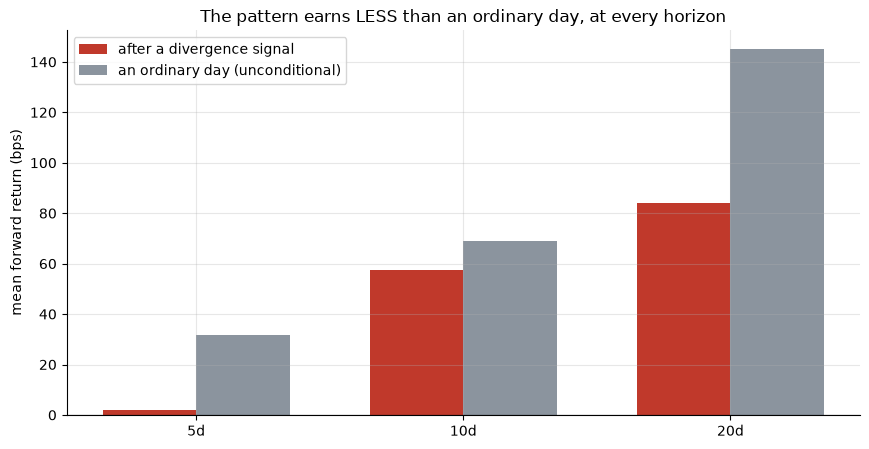

signal: [1.9, 57.6, 84.1]  unconditional: [31.6, 68.8, 145.3]


In [2]:
if HAVE_REAL:
    hs = {h: st.headline_stats(TAPE, EVENTS, h) for h in (5, 10, 20)}
    sig = [hs[h]['sig_mean_bps'] for h in (5, 10, 20)]
    base = [hs[h]['base_mean_bps'] for h in (5, 10, 20)]
else:
    sig = [R['headline'][h][0] for h in (5, 10, 20)]
    base = [R['headline'][h][1] for h in (5, 10, 20)]
x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(x - w/2, sig, w, color=RED, label='after a divergence signal')
ax.bar(x + w/2, base, w, color=GREY, label='an ordinary day (unconditional)')
ax.set_xticks(x); ax.set_xticklabels(['5d', '10d', '20d'])
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return (bps)')
ax.set_title('The pattern earns LESS than an ordinary day, at every horizon')
ax.legend(); plt.tight_layout(); plt.show()
print('signal:', [round(v,1) for v in sig], ' unconditional:', [round(v,1) for v in base])

That's the whole headline right there: the red bars (after a divergence signal) sit **below** the grey bars (an ordinary day) at every horizon. If the pattern carried real information, red should be taller than grey — instead it's smaller, every single time.

**Maybe it's just noisy — how does it do against pure luck?**

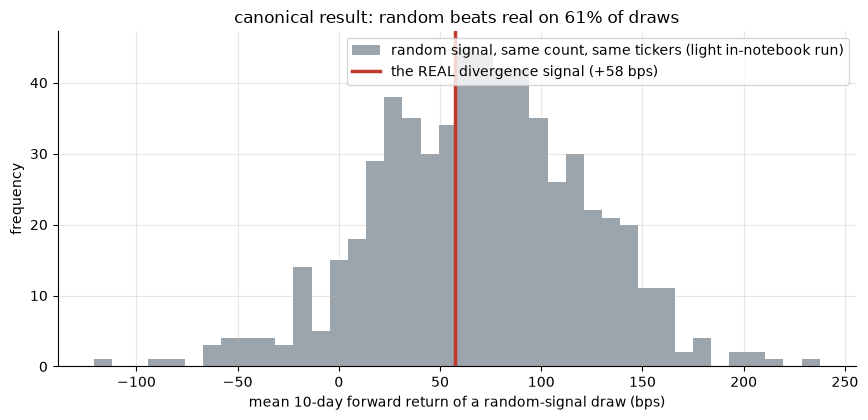

real signal +57.6 bps vs canonical placebo mean +71.0 bps -> p(random >= real) = 0.613


In [3]:
if HAVE_REAL:
    pl10 = st.random_signal_placebo(TAPE, EVENTS, 10, n_draws_per_seed=100, n_seeds=6)
    obs, draws = pl10['obs']*1e4, pl10['draws']*1e4
else:
    obs = R['placebo'][10][0]
    rng = np.random.default_rng(669)
    draws = rng.normal(R['placebo'][10][1], R['placebo'][10][2], 2400)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85,
        label='random signal, same count, same tickers (light in-notebook run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'the REAL divergence signal ({obs:+.0f} bps)')
ax.set_xlabel('mean 10-day forward return of a random-signal draw (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"canonical result: random beats real on {R['placebo'][10][3]*100:.0f}% of draws")
ax.legend(); plt.tight_layout(); plt.show()
print(f"real signal {obs:+.1f} bps vs canonical placebo mean "
      f"{R['placebo'][10][1]:+.1f} bps -> p(random >= real) = {R['placebo'][10][3]:.3f}")

The red line — the real pattern — sits **inside** the cloud of random draws, not off to the right of it. At the 10-day horizon, a random signal of the identical size beats the real thing on **61%** of tries. That's the cleanest possible verdict: this isn't a weak signal, it's statistically indistinguishable from — and slightly worse than — chance.

**One more honest check: is the basket just flat, so a coin flip looks good by default?**

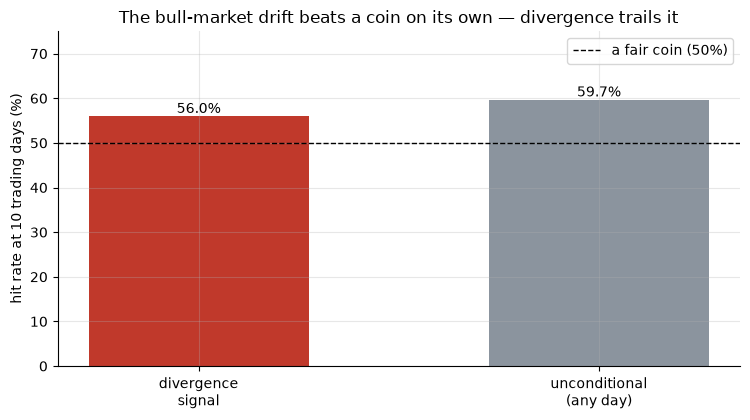

signal hit rate 56.0%  vs unconditional 59.7%


In [4]:
if HAVE_REAL:
    fwd10 = st.basket_forward_series(TAPE, 10)
    allv = np.concatenate([s.dropna().values for s in fwd10.values()])
    uncond_hit = float((allv > 0).mean()) * 100
    sig_hit = hs[10]['hit_rate'] * 100
else:
    uncond_hit, sig_hit = R['uncond_hit10'], R['headline'][10][6]
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['divergence\nsignal', 'unconditional\n(any day)'], [sig_hit, uncond_hit],
       color=[RED, GREY], width=.55)
ax.axhline(50, ls='--', c='k', lw=1, label='a fair coin (50%)')
for i,v in enumerate([sig_hit, uncond_hit]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('hit rate at 10 trading days (%)'); ax.set_ylim(0, 75)
ax.set_title('The bull-market drift beats a coin on its own — divergence trails it')
ax.legend(); plt.tight_layout(); plt.show()
print(f'signal hit rate {sig_hit:.1f}%  vs unconditional {uncond_hit:.1f}%')

Both bars clear 50% — this basket simply went up a lot from 2010 to 2026. But the divergence signal (56.0%) sits **below** the unconditional bar (59.7%), not above it. "Beats a coin" was never the right question — "beats doing nothing" is, and the pattern fails that one too.

## 5 · The verdict

- **Signal — None.** Divergence-flagged trades trail the unconditional baseline at every horizon (5, 10, 20 days); a random signal of the same size beats the real pattern most of the time.
- **Tradability — Mirage.** There's no gross edge to protect from costs in the first place, and one trade lost **−14.3%** on its own.
- **"Beats a random signal?" — Busted.** The fairest control available — same tickers, same count, random timing — outperforms the textbook pattern.

## 6 · Going further 🚪

- **The visual trap.** RSI divergence is easy to *see* on a chart because you're choosing which two swing lows to connect after the fact. Algorithmic, non-cherry-picked detection removes that freedom — and the edge disappears with it.
- **Sibling studies:** [109-obv-divergence](../../109-obv-divergence/) runs the same divergence *shape* on volume instead of RSI — also a Mirage. [75-knee-jerk](../../75-knee-jerk/) tests plain RSI(2) mean reversion (no divergence at all) and finds something real — worth reading side by side with this study to see which momentum ideas hold up and which don't.

*Think a tighter swing-detection window or a different oscillator would resurrect the pattern? Show a net, certifiable edge against the random-signal control — not just against 50% — and we'll take another look.*